# TPC-DS Workload Generator Comparison

Reference workload: `tpcds` (the 99 hand-written TPC-DS queries).
Systems under evaluation: any `gpt_generated_*` workload (highlighted); the
remaining generators are shown as muted baselines.

The metrics reported here mirror the CIDR evaluation workbook
(`Evaluation_sheet.xlsx`) so the tables drop straight into the paper:

| Notebook section | Workbook sheet | What it answers |
|---|---|---|
| 1 · Correctness       | §1 Correctness         | Are generated queries valid and runnable? |
| 2 · Schema diversity  | §2 Schema diversity    | Do we touch all schema elements, uniformly? |
| 3 · Structural diversity | §3 Structural diversity | Are the physical plans structurally distinct? |
| 4 · Headline summary  | §6 Backbone ablation (B) | The five headline numbers, side by side. |

Higher is better on every metric below. `tpcds` is the hand-crafted reference,
overlaid for comparison — **not** a target ceiling for the diversity metrics.

In [102]:
import os, json
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

# --- choose one or more result CSVs to combine -------------------------------
# List every file you want in the comparison. Rows are keyed by `workload`;
# if the same workload name appears in more than one file, the LAST file wins,
# so put newer runs later in the list.
CSVS = [
    "results/tpcds_baseline_diversity_comparison_1000.csv",
    "results/tpcds_baseline_diversity_comparison_1000_v3.csv",
    "results/tpcds_baseline_diversity_comparison_1000_v4.csv",
    "results/sql_factory_1000_tpcds.csv",
    "results/gpt_generated_100_tpcds_v5.csv",
    "results/gpt_generated_1000_tpcds_v5.csv",
    "results/gpt_generated_1000_tpcds_v6.csv",
    "results/gpt_generated_1000_tpcds_v6_exotic.csv",
    "results/gpt_generated_1000_tpcds_v7.csv",
    "results/gpt_generated_1000_tpcds_v71.csv",
    "results/gpt_generated_1000_tpcds_v72.csv",
    "results/gpt_generated_1000_tpcds_v8.csv",
    "results/gpt_generated_1000_tpcds_v9.csv",
    "results/gpt_generated_1000_tpcds_v91.csv",
    "results/gpt_generated_100_tpcds_new.csv",
    "results/gpt_generated_1000_tpcds_new.csv",
]
REF = "tpcds"          # hand-crafted ground-truth workload

WORKLOAD_ROOTS = [
    Path("../../Workloads"),               # local repo copy (this machine)
    Path("/mnt/primary/Main/Workloads"),   # remote mount
]

# --- load + merge ------------------------------------------------------------
frames = []
for path in CSVS:
    f = pd.read_csv(path)
    f["source_file"] = os.path.basename(path)
    frames.append(f)
df = pd.concat(frames, ignore_index=True)
df = df.drop_duplicates(subset="workload", keep="last").set_index("workload")

# --- classify workloads: reference / ours / baseline -------------------------
OURS      = [w for w in df.index if "gpt_generated" in w and w != REF]
GENS      = [w for w in df.index if w != REF]
BASELINES = [w for w in GENS if w not in OURS]
ORDER     = OURS + BASELINES                    # generators, ours first
ROWS      = [REF] + ORDER                        # reference on top

# --- colours: reference black, ours warm, baselines muted --------------------
_ours_palette = ["#c2410c", "#ea580c", "#f97316", "#fb923c"]
COL = {w: "#b8b8b8" for w in df.index}
for i, w in enumerate(OURS):
    COL[w] = _ours_palette[i % len(_ours_palette)]
COL[REF] = "#111111"

# --- shared table styler -----------------------------------------------------
def show(tbl, fmt="{:.3f}"):
    """Reference row greyed + italic, our workloads highlighted warm."""
    def hl(row):
        if row.name == REF:
            return ["background-color:#f3f4f6;font-style:italic"] * len(row)
        if row.name in OURS:
            return ["background-color:#fff1e6;font-weight:600"] * len(row)
        return [""] * len(row)
    sty = tbl.style.apply(hl, axis=1)
    return sty.format(fmt) if fmt else sty

print(f"{len(df)} workloads loaded from {len(CSVS)} file(s)")
print(f"  reference : {REF}")
print(f"  ours      : {OURS}")
print(f"  baselines : {BASELINES}")
df[["source_file", "query_count"]]

21 workloads loaded from 16 file(s)
  reference : tpcds
  ours      : ['gpt_generated_tpcds', 'gpt_generated_1000_tpcds_v3', 'gpt_generated_1000_tpcds_v4', 'gpt_generated_100_tpcds_v5', 'gpt_generated_1000_tpcds_v5', 'gpt_generated_1000_tpcds_v6', 'gpt_generated_1000_tpcds_v6_exotic', 'gpt_generated_1000_tpcds_v7', 'gpt_generated_1000_tpcds_v71', 'gpt_generated_1000_tpcds_v72', 'gpt_generated_1000_tpcds_v8', 'gpt_generated_1000_tpcds_v9', 'gpt_generated_1000_tpcds_v91', 'gpt_generated_100_tpcds_new', 'gpt_generated_1000_tpcds_new']
  baselines : ['bootstrapping_lcm_1000_tpcds', 'e2etune_1000_tpcds', 'sqlbarber_1000_tpcds', 'sqlstorm_1000_tpcds', 'sql_factory_1000_tpcds']


,source_file,query_count
workload,,
tpcds,tpcds_baseline_diversity_comparison_1000.csv,99
bootstrapping_lcm_1000_tpcds,tpcds_baseline_diversity_comparison_1000.csv,1000
e2etune_1000_tpcds,tpcds_baseline_diversity_comparison_1000.csv,1000
gpt_generated_tpcds,tpcds_baseline_diversity_comparison_1000.csv,1000
sqlbarber_1000_tpcds,tpcds_baseline_diversity_comparison_1000.csv,1000
sqlstorm_1000_tpcds,tpcds_baseline_diversity_comparison_1000.csv,1000
gpt_generated_1000_tpcds_v3,tpcds_baseline_diversity_comparison_1000_v3.csv,1000
gpt_generated_1000_tpcds_v4,tpcds_baseline_diversity_comparison_1000_v4.csv,1000
sql_factory_1000_tpcds,sql_factory_1000_tpcds.csv,1000


## Load the generation logs

Read each workload's `generation_report.json` for the overhead figures and (for
our generator) the design-mix breakdowns. Mirrors `analysis.load_generation_overhead`
but stays dependency-free so the notebook runs anywhere.

In [103]:
def find_report(workload):
    for root in WORKLOAD_ROOTS:
        p = Path(root) / workload / "generation_report.json"
        if p.exists():
            with p.open(encoding="utf-8") as fh:
                return json.load(fh)
    return None

reports = {w: r for w in df.index if (r := find_report(w)) is not None}

def overhead_row(rep):
    model = rep.get("model") or {}
    par   = rep.get("parallelism") or {}
    val   = rep.get("validation") or {}
    nq, dur = rep.get("num_queries"), rep.get("duration_s")
    row = {
        "generator":   rep.get("generator") or rep.get("baseline"),
        "queries":     nq,
        "duration_s":  dur,
        "duration_min": (dur / 60.0) if dur else np.nan,
        "queries_per_min":   (nq / (dur / 60.0)) if (dur and nq) else np.nan,
        "seconds_per_query": (dur / nq) if (dur and nq) else np.nan,
        "workers":     par.get("generation_workers"),
        "reasoning":   rep.get("reasoning") or model.get("reasoning"),
        "candidates":  val.get("total_candidates_generated"),
        "rejected":    val.get("num_invalid_queries_rejected"),
    }
    if row["candidates"]:
        row["rejection_rate"]      = (row["rejected"] or 0) / row["candidates"]
        row["candidates_per_query"] = row["candidates"] / nq if nq else np.nan
    else:
        row["rejection_rate"] = row["candidates_per_query"] = np.nan
    return row

overhead = pd.DataFrame({w: overhead_row(r) for w, r in reports.items()}).T
overhead = overhead.reindex([w for w in ORDER if w in overhead.index])
missing = [w for w in ORDER if w not in overhead.index]
if missing:
    print("no generation_report.json for:", missing)


no generation_report.json for: ['gpt_generated_1000_tpcds_v4', 'gpt_generated_1000_tpcds_v5']


## 1 · Correctness  (workbook §1)

Validity is enforced by prompt-level grounding, not a rewrite loop. `validity %`
= queries that parsed **and** executed / queries requested. Higher is better.

In [104]:
correctness = pd.DataFrame({
    "queries":    df["query_count"],
    "ok":         df["ok"],
    "failed":     df["failed"],
    "validity %": df["ok"] / df["query_count"] * 100,
}).loc[ROWS]

show(correctness, None).format({
    "queries": "{:.0f}", "ok": "{:.0f}", "failed": "{:.0f}", "validity %": "{:.1f}",
})

,queries,ok,failed,validity %
workload,,,,
tpcds,99,99,0,100.0
gpt_generated_tpcds,1000,1000,0,100.0
gpt_generated_1000_tpcds_v3,1000,1000,0,100.0
gpt_generated_1000_tpcds_v4,1000,1000,0,100.0
gpt_generated_100_tpcds_v5,100,100,0,100.0
gpt_generated_1000_tpcds_v5,991,991,0,100.0
gpt_generated_1000_tpcds_v6,1000,1000,0,100.0
gpt_generated_1000_tpcds_v6_exotic,1000,1000,0,100.0
gpt_generated_1000_tpcds_v7,1000,1000,0,100.0


## 2 · Schema diversity  (workbook §2)

*Coverage* — do we touch all schema elements; *usage entropy* — do we use them
uniformly; *unique table-set ratio* — are table combinations varied. All in
`[0, 1]`, higher is better.

In [105]:
SCHEMA = {
    "table_coverage":          "Table cov.",
    "column_coverage":         "Column cov.",
    "join_edge_coverage":      "Join-edge cov.",
    "table_usage_entropy":     "Table entropy",
    "column_usage_entropy":    "Column entropy",
    "join_edge_usage_entropy": "Join-edge entropy",
    "unique_table_set_ratio":  "Unique table-set ratio",
}
schema = df.loc[ROWS, list(SCHEMA)].astype(float).rename(columns=SCHEMA)
show(schema)

,Table cov.,Column cov.,Join-edge cov.,Table entropy,Column entropy,Join-edge entropy,Unique table-set ratio
workload,,,,,,,
tpcds,1.000,0.581,0.683,0.845,0.881,0.824,0.657
gpt_generated_tpcds,1.000,0.694,1.000,0.896,0.848,0.872,0.613
gpt_generated_1000_tpcds_v3,1.000,0.984,1.000,0.993,0.894,0.934,0.954
gpt_generated_1000_tpcds_v4,1.000,0.986,1.000,0.992,0.886,0.927,0.919
gpt_generated_100_tpcds_v5,1.000,0.732,0.951,0.981,0.926,0.963,0.990
gpt_generated_1000_tpcds_v5,1.000,0.991,1.000,0.989,0.905,0.944,0.929
gpt_generated_1000_tpcds_v6,1.000,0.979,1.000,0.991,0.884,0.922,0.929
gpt_generated_1000_tpcds_v6_exotic,1.000,0.972,1.000,0.989,0.885,0.923,0.938
gpt_generated_1000_tpcds_v7,1.000,0.991,1.000,0.991,0.889,0.937,0.918


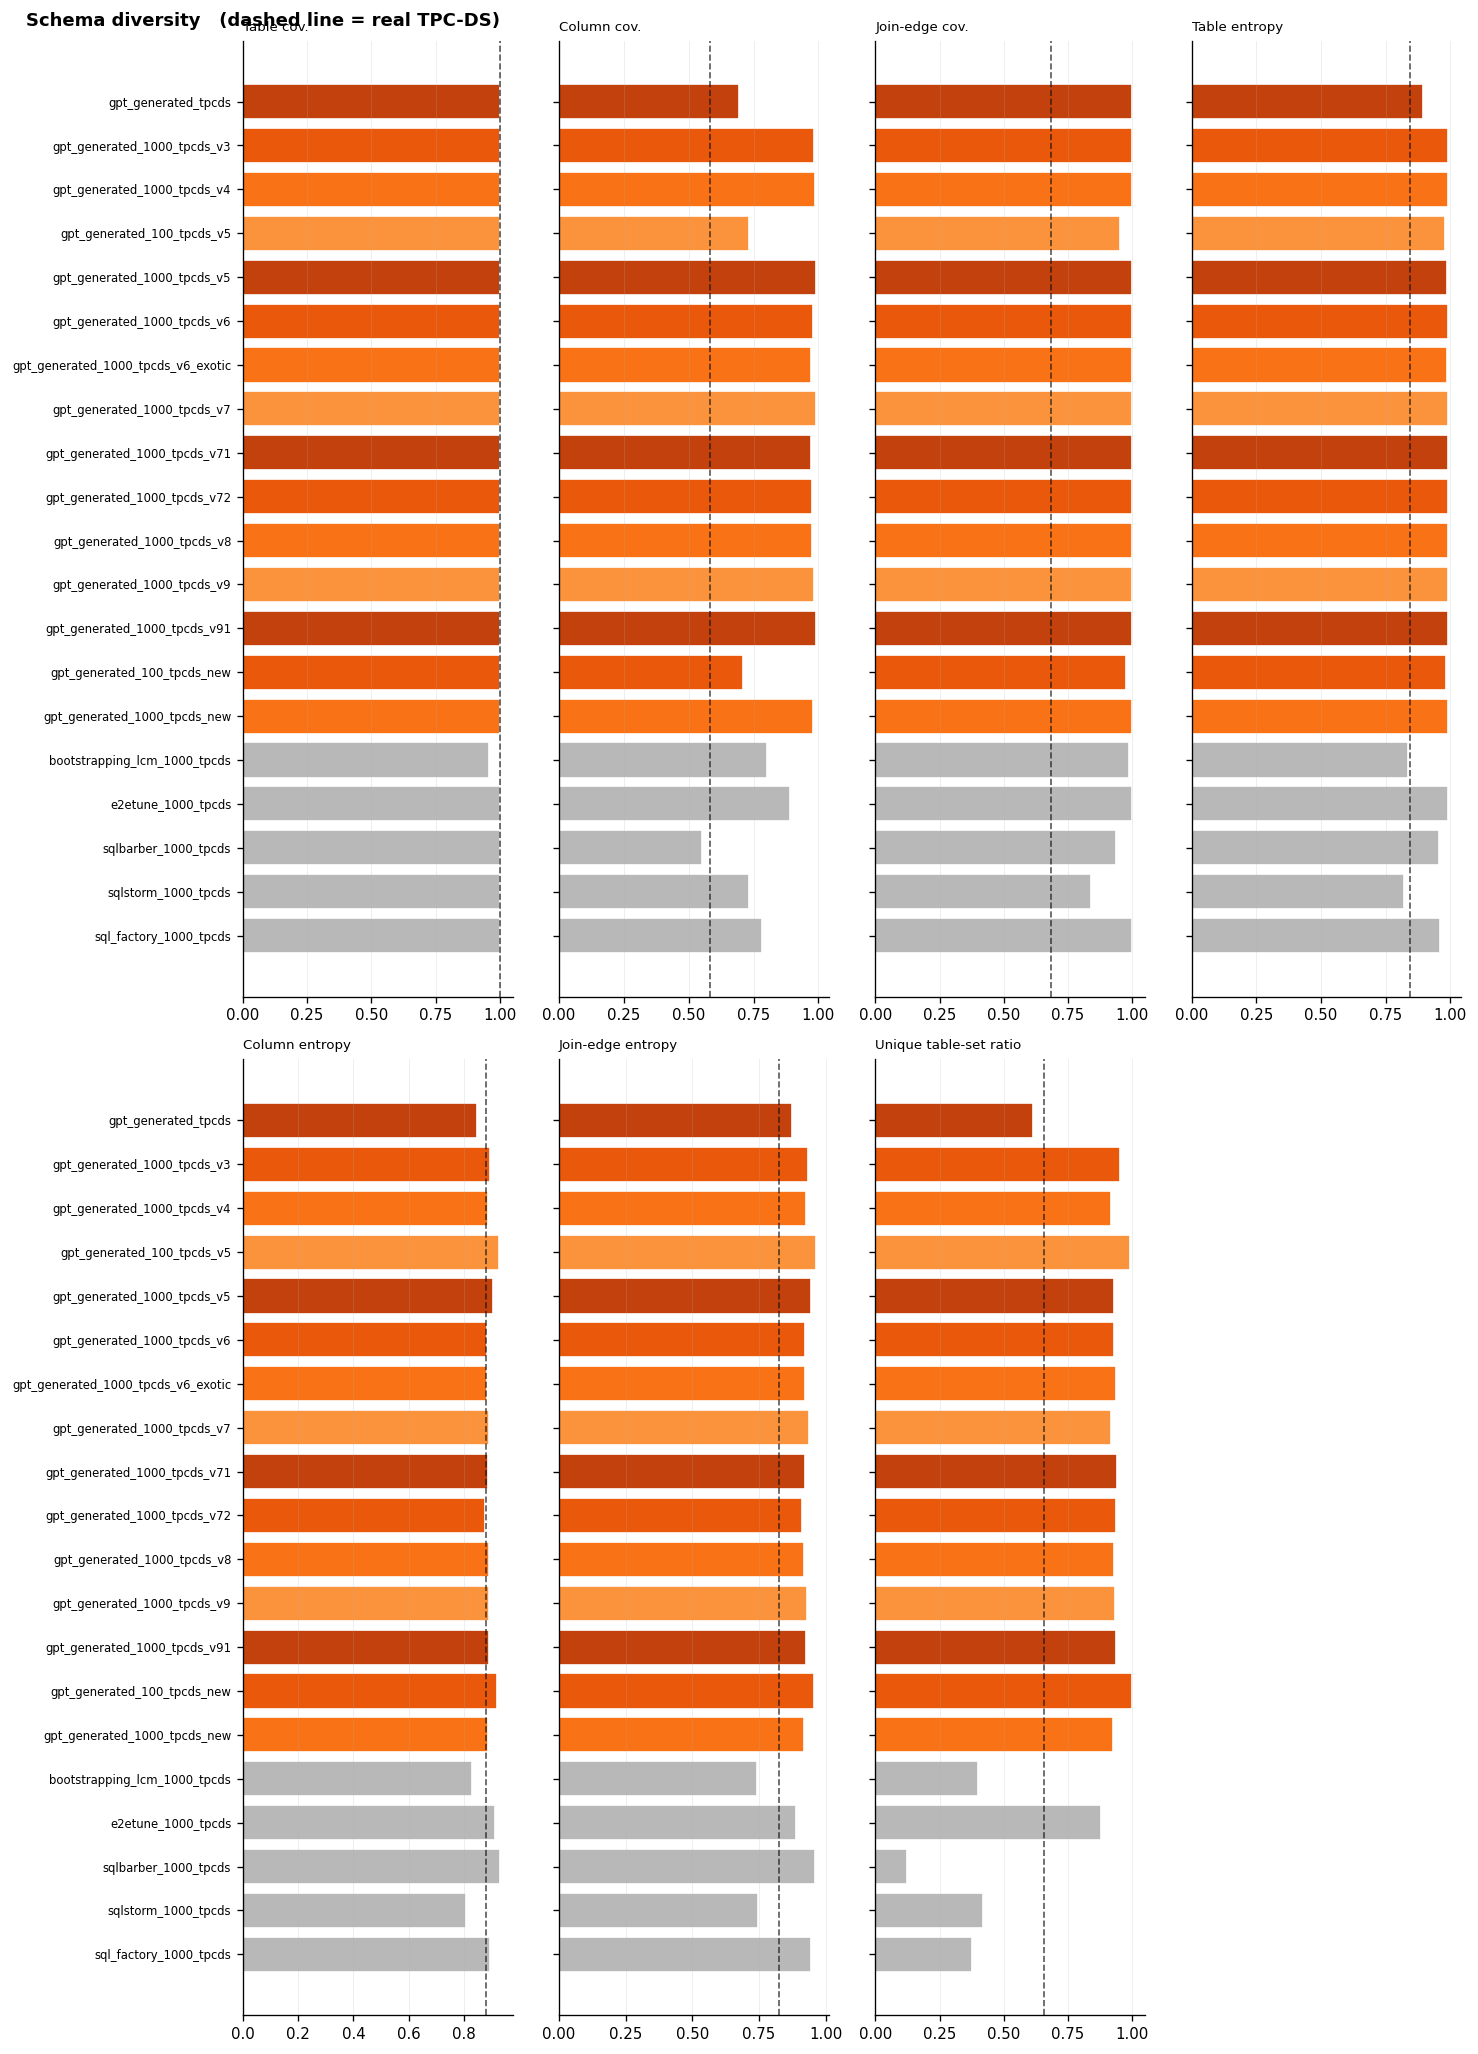

In [106]:
def metric_grid(metrics, title, ncols=4):
    """One horizontal-bar panel per metric; reference drawn as a dashed line."""
    n = len(metrics)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.1 * ncols, 0.42 * len(ORDER) * nrows + 0.6))
    axes = np.atleast_1d(axes).ravel()
    for ax, (col, label) in zip(axes, metrics.items()):
        vals = df.loc[ORDER, col].astype(float)
        ax.barh(range(len(ORDER)), vals.values,
                color=[COL[w] for w in ORDER], edgecolor="white")
        ax.axvline(float(df.loc[REF, col]), color=COL[REF], ls="--", lw=1, alpha=.7)
        ax.set_yticks(range(len(ORDER)))
        ax.set_yticklabels(ORDER if ax in (axes[0], axes[ncols]) else [], fontsize=7)
        ax.invert_yaxis()
        ax.set_title(label, fontsize=8, loc="left")
        ax.grid(axis="y", visible=False)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"{title}   (dashed line = real TPC-DS)",
                 x=0.02, ha="left", fontweight="bold")
    plt.tight_layout(); plt.show()

metric_grid(SCHEMA, "Schema diversity")

## 3 · Structural diversity  (workbook §3)

Plan-level distinctness from the executed physical plans. *Vendi score* is the
interpretable "effective number" of distinct plans; *mean NN distance* separates
global diversity from a handful of outliers. Higher is better.

In [107]:
STRUCT = {
    "plan_graph_uniqueness_ratio":     "Unique plan-graph ratio",
    "n_operator_types_observed":       "Operator types",
    "operator_type_entropy":           "Operator type entropy",
    "mean_nearest_neighbour_distance": "Mean NN distance",
    "plan_graph_vendi_score":          "Plan-graph Vendi",
}
struct = df.loc[ROWS, list(STRUCT)].astype(float).rename(columns=STRUCT)
show(struct, None).format({
    "Unique plan-graph ratio": "{:.3f}", "Operator types": "{:.0f}",
    "Operator type entropy": "{:.3f}", "Mean NN distance": "{:.3f}",
    "Plan-graph Vendi": "{:.2f}",
})

,Unique plan-graph ratio,Operator types,Operator type entropy,Mean NN distance,Plan-graph Vendi
workload,,,,,
tpcds,0.848,29,0.680,0.243,22.26
gpt_generated_tpcds,0.921,27,0.709,0.186,52.04
gpt_generated_1000_tpcds_v3,1.000,33,0.650,0.272,64.58
gpt_generated_1000_tpcds_v4,0.996,32,0.656,0.256,61.40
gpt_generated_100_tpcds_v5,1.000,31,0.669,0.334,23.72
gpt_generated_1000_tpcds_v5,1.000,32,0.672,0.267,58.02
gpt_generated_1000_tpcds_v6,1.000,33,0.661,0.292,71.62
gpt_generated_1000_tpcds_v6_exotic,1.000,33,0.663,0.296,72.34
gpt_generated_1000_tpcds_v7,1.000,30,0.677,0.223,54.14


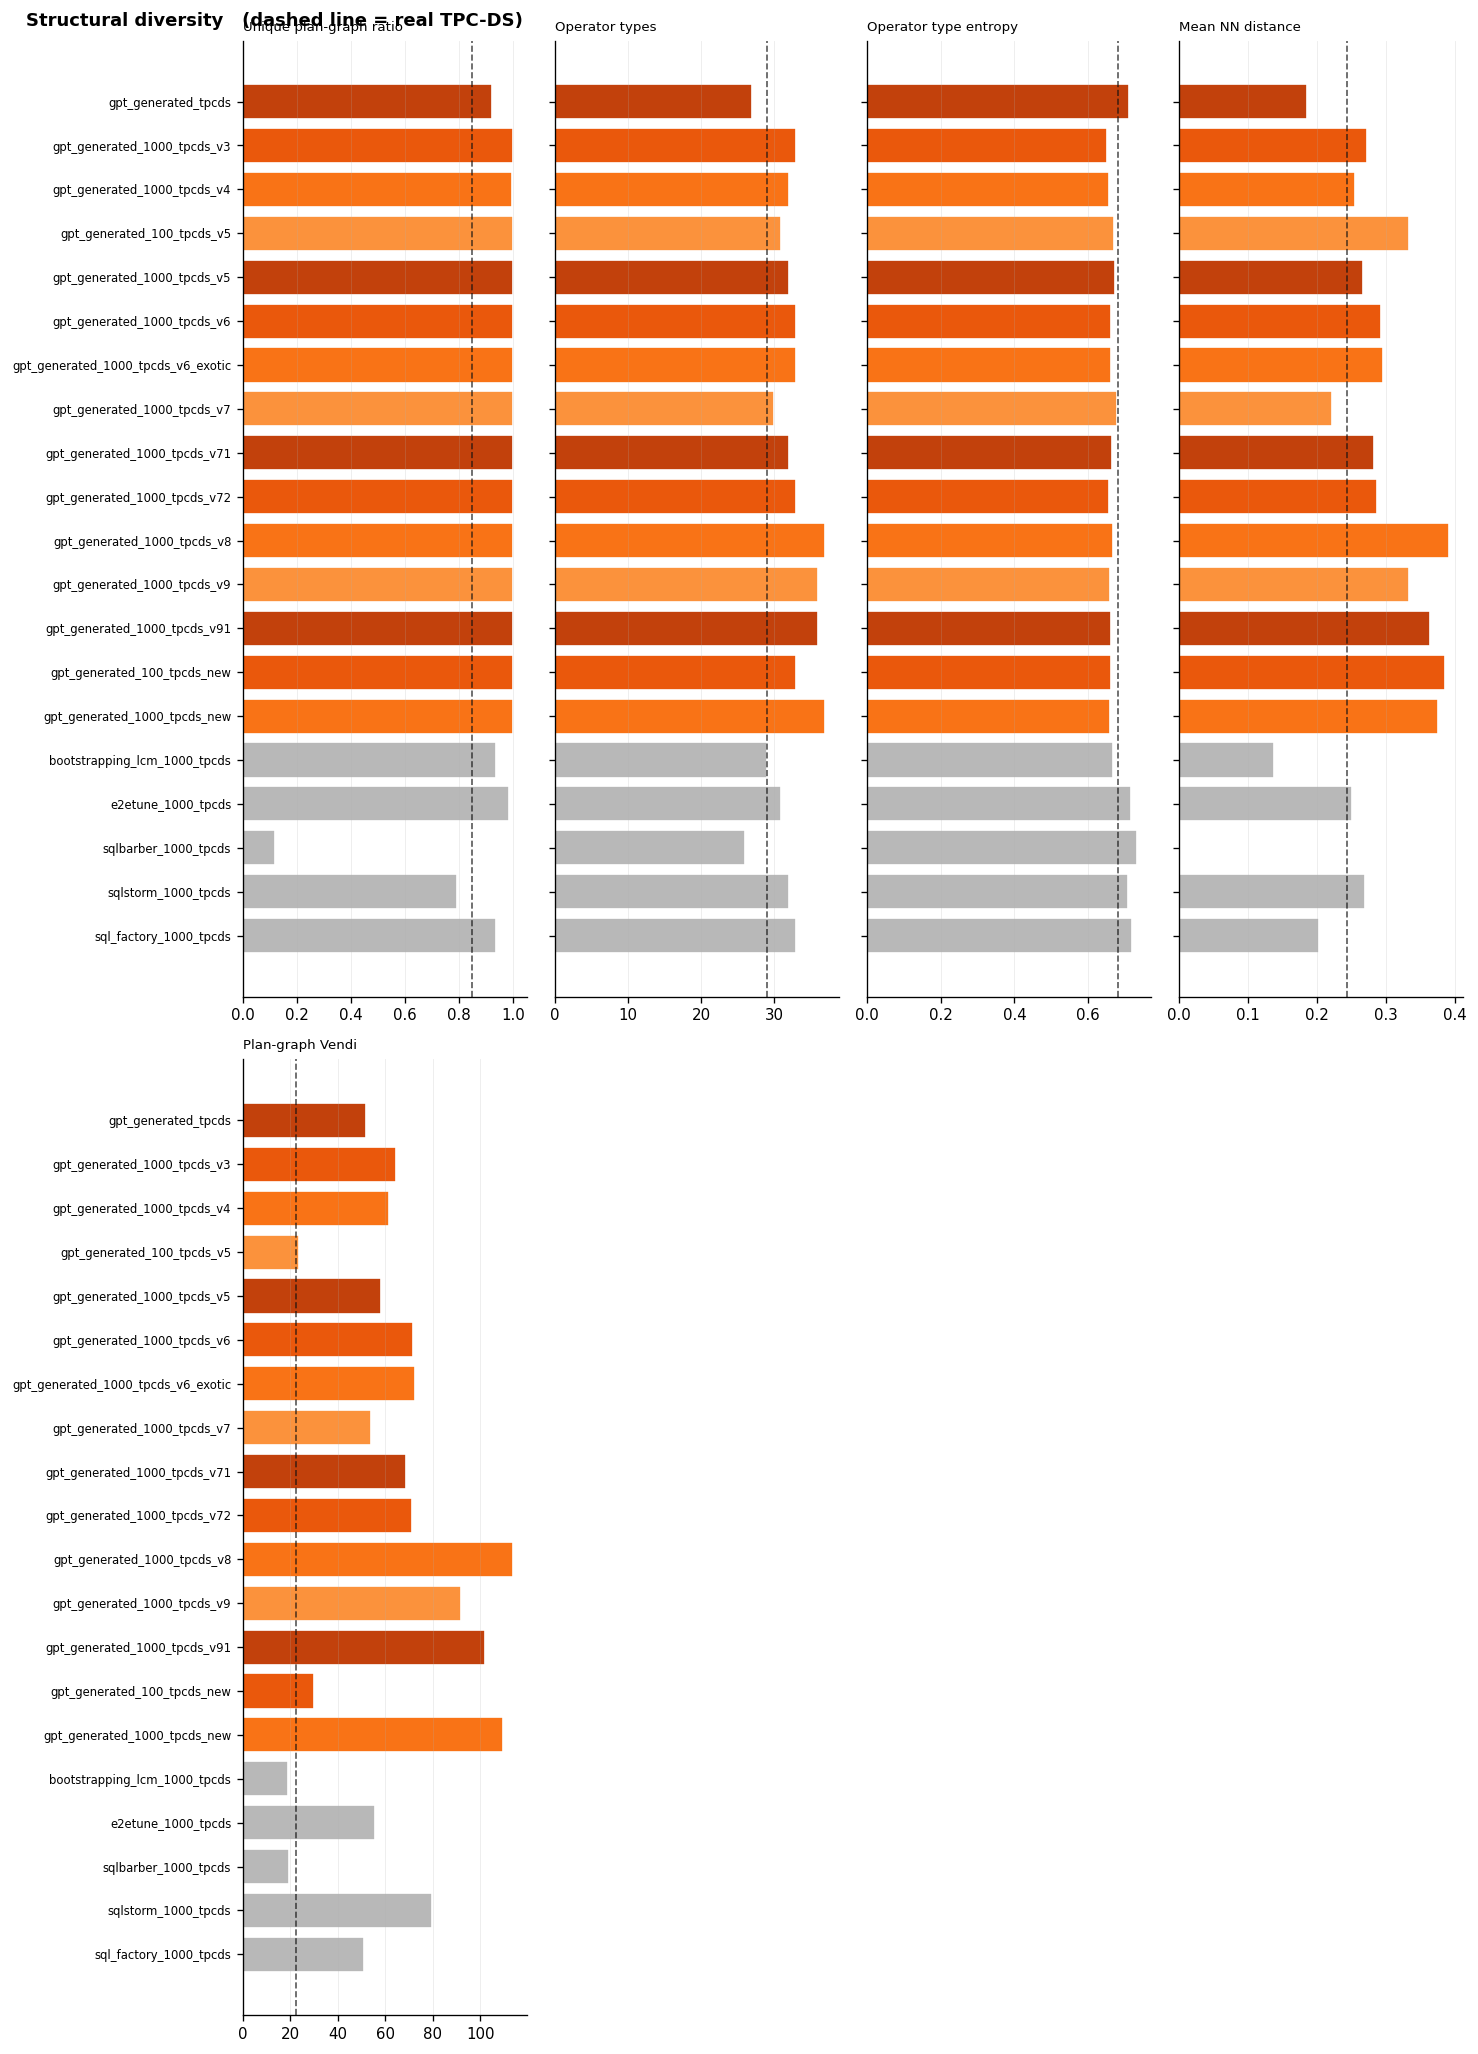

In [108]:
metric_grid(STRUCT, "Structural diversity")

## 4 · Headline summary  (workbook §6B)

The five numbers that go in the ablation / comparison grid: one correctness, two
schema-diversity, two structural-diversity. `tpcds` is the reference row.

In [109]:
headline = pd.DataFrame({
    "validity %":              df["ok"] / df["query_count"] * 100,
    "join-edge cov.":          df["join_edge_coverage"],
    "unique table-set ratio":  df["unique_table_set_ratio"],
    "unique plan-graph ratio": df["plan_graph_uniqueness_ratio"],
    "plan-graph Vendi":        df["plan_graph_vendi_score"],
}).loc[ROWS]

show(headline, None).format({
    "validity %": "{:.1f}", "join-edge cov.": "{:.3f}",
    "unique table-set ratio": "{:.3f}", "unique plan-graph ratio": "{:.3f}",
    "plan-graph Vendi": "{:.2f}",
})

,validity %,join-edge cov.,unique table-set ratio,unique plan-graph ratio,plan-graph Vendi
workload,,,,,
tpcds,100.0,0.683,0.657,0.848,22.26
gpt_generated_tpcds,100.0,1.000,0.613,0.921,52.04
gpt_generated_1000_tpcds_v3,100.0,1.000,0.954,1.000,64.58
gpt_generated_1000_tpcds_v4,100.0,1.000,0.919,0.996,61.40
gpt_generated_100_tpcds_v5,100.0,0.951,0.990,1.000,23.72
gpt_generated_1000_tpcds_v5,100.0,1.000,0.929,1.000,58.02
gpt_generated_1000_tpcds_v6,100.0,1.000,0.929,1.000,71.62
gpt_generated_1000_tpcds_v6_exotic,100.0,1.000,0.938,1.000,72.34
gpt_generated_1000_tpcds_v7,100.0,1.000,0.918,1.000,54.14


## 5 · Generation overhead  (workbook §5)

Wall-clock cost of producing each workload. `tpcds` is hand-crafted, so it has no
generation cost and is absent here. Lower time / higher throughput is better.

In [110]:
ov = overhead.copy()
ov_tbl = ov[["queries", "duration_min", "queries_per_min", "seconds_per_query",
             "workers", "candidates", "rejection_rate"]].astype(float)
show(ov_tbl).format({
    "queries": "{:.0f}", "duration_min": "{:.1f}", "queries_per_min": "{:.2f}",
    "seconds_per_query": "{:.1f}", "workers": "{:.0f}",
    "candidates": "{:.0f}", "rejection_rate": "{:.1%}",
})

,queries,duration_min,queries_per_min,seconds_per_query,workers,candidates,rejection_rate
gpt_generated_tpcds,1000,118.4,8.45,7.1,64,1016,1.6%
gpt_generated_1000_tpcds_v3,1000,426.7,2.34,25.6,32,1000,0.0%
gpt_generated_100_tpcds_v5,100,21.3,4.70,12.8,64,100,0.0%
gpt_generated_1000_tpcds_v6,1000,85.6,11.68,5.1,64,1000,0.0%
gpt_generated_1000_tpcds_v6_exotic,1000,122.3,8.17,7.3,64,1000,0.0%
gpt_generated_1000_tpcds_v7,1000,125.3,7.98,7.5,64,1000,0.0%
gpt_generated_1000_tpcds_v71,1000,92.1,10.86,5.5,64,1000,0.0%
gpt_generated_1000_tpcds_v72,1000,131.3,7.62,7.9,64,1000,0.0%
gpt_generated_1000_tpcds_v8,1000,270.4,3.70,16.2,64,1000,0.0%
gpt_generated_1000_tpcds_v9,1000,561.6,1.78,33.7,64,1000,0.0%


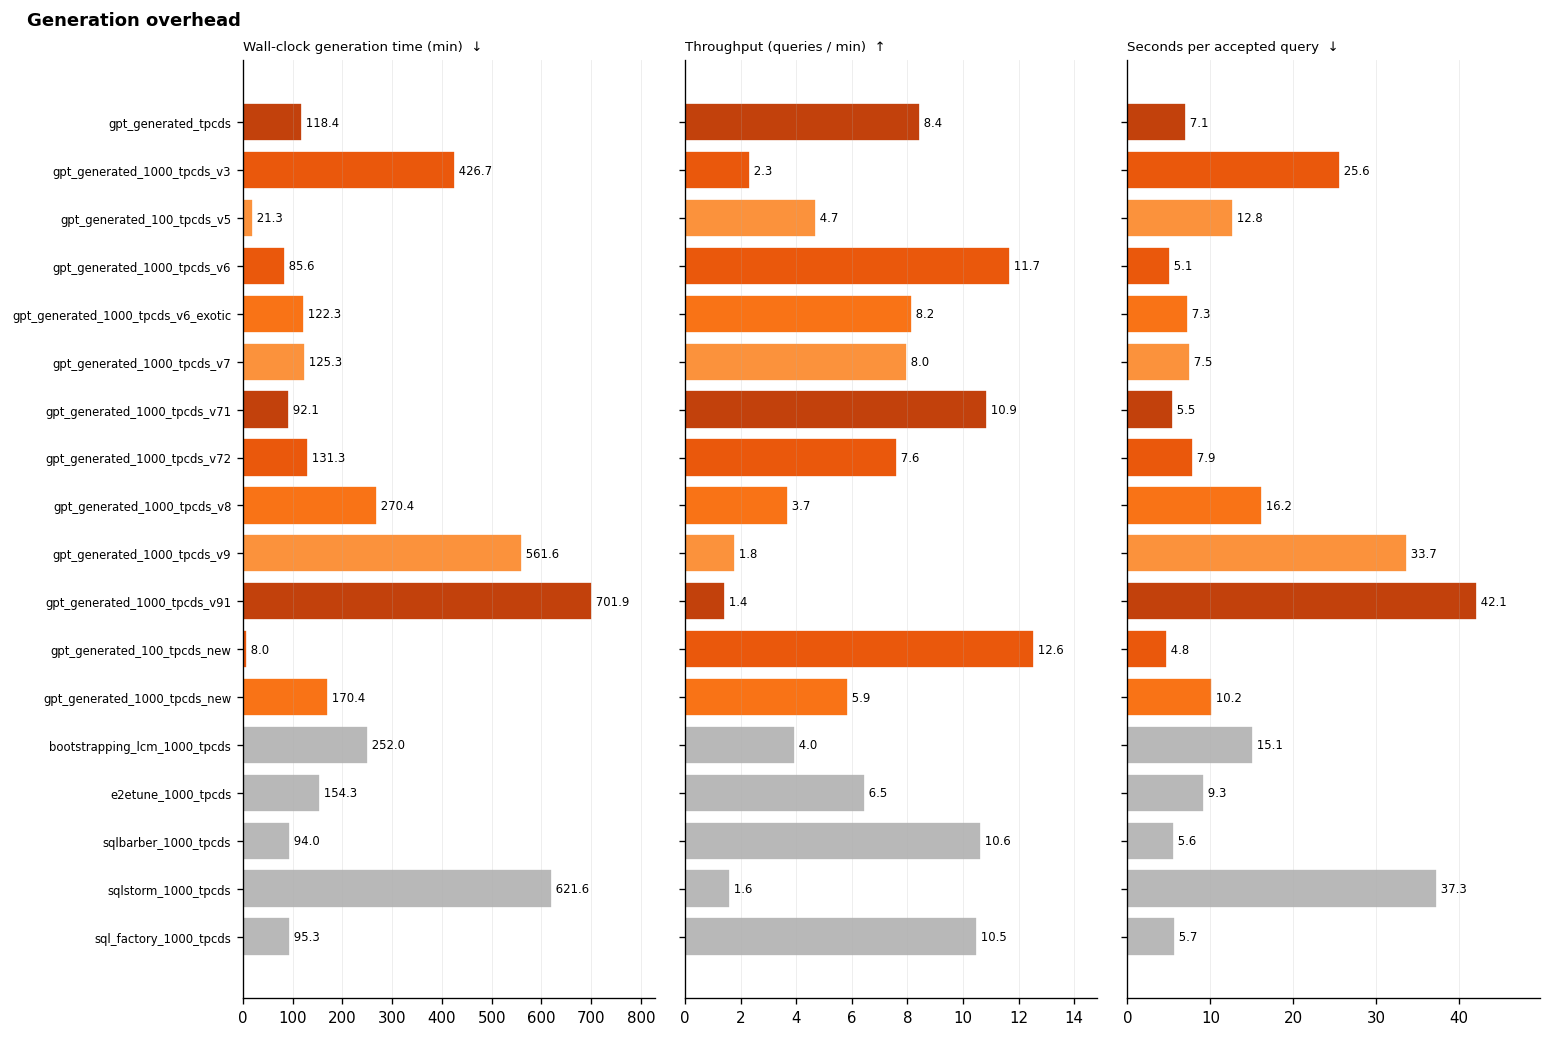

In [111]:
gens = list(ov.index)
fig, axes = plt.subplots(1, 3, figsize=(13, 0.42 * len(gens) + 1.2))
panels = [
    ("duration_min",      "Wall-clock generation time (min)  ↓"),
    ("queries_per_min",   "Throughput (queries / min)  ↑"),
    ("seconds_per_query", "Seconds per accepted query  ↓"),
]
for ax, (col, title) in zip(axes, panels):
    vals = ov[col].astype(float)
    ax.barh(range(len(gens)), vals.values,
            color=[COL[w] for w in gens], edgecolor="white")
    for i, v in enumerate(vals.values):
        ax.text(v, i, f" {v:,.1f}", va="center", fontsize=7)
    ax.set_yticks(range(len(gens)))
    ax.set_yticklabels(gens if ax is axes[0] else [], fontsize=7)
    ax.invert_yaxis(); ax.set_title(title, fontsize=8, loc="left")
    ax.grid(axis="y", visible=False); ax.margins(x=0.18)
fig.suptitle("Generation overhead", x=0.02, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

In [112]:
output_file = "tpcds_generator_analysis_tables.xlsx"

tables = {
    "Correctness": correctness,
    "Schema diversity": schema,
    "Structural diversity": struct,
    "Overhead": overhead,
    "Headline summary": headline,
}

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for sheet_name, table in tables.items():
        export_table = table.rename_axis("workload").reset_index()
        export_table.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False,
        )

        worksheet = writer.sheets[sheet_name]

        # Turn the range into a formatted Excel table
        rows, cols = export_table.shape
        worksheet.add_table(
            0,
            0,
            rows,
            cols - 1,
            {
                "name": "Table_" + sheet_name.replace(" ", "_"),
                "columns": [{"header": column} for column in export_table.columns],
                "style": "Table Style Medium 2",
            },
        )

        # Adjust column widths
        for column_number, column in enumerate(export_table.columns):
            width = max(
                len(str(column)),
                export_table[column].astype(str).map(len).max(),
            )
            worksheet.set_column(
                column_number,
                column_number,
                min(width + 2, 40),
            )

print(f"Created: {output_file}")

ModuleNotFoundError: No module named 'xlsxwriter'

## (6) · The queries themselves — structural profile

How complex are the generated queries? Each panel is one SQL feature; the bar
spans the workload's **min–max** range, the vertical tick marks the **mean** and
the dot marks the **median**. The dashed line is the real TPC-DS mean. This is
the query-shape view: are the queries trivial single-scans or deep multi-join
analytics, and how wide is the spread?

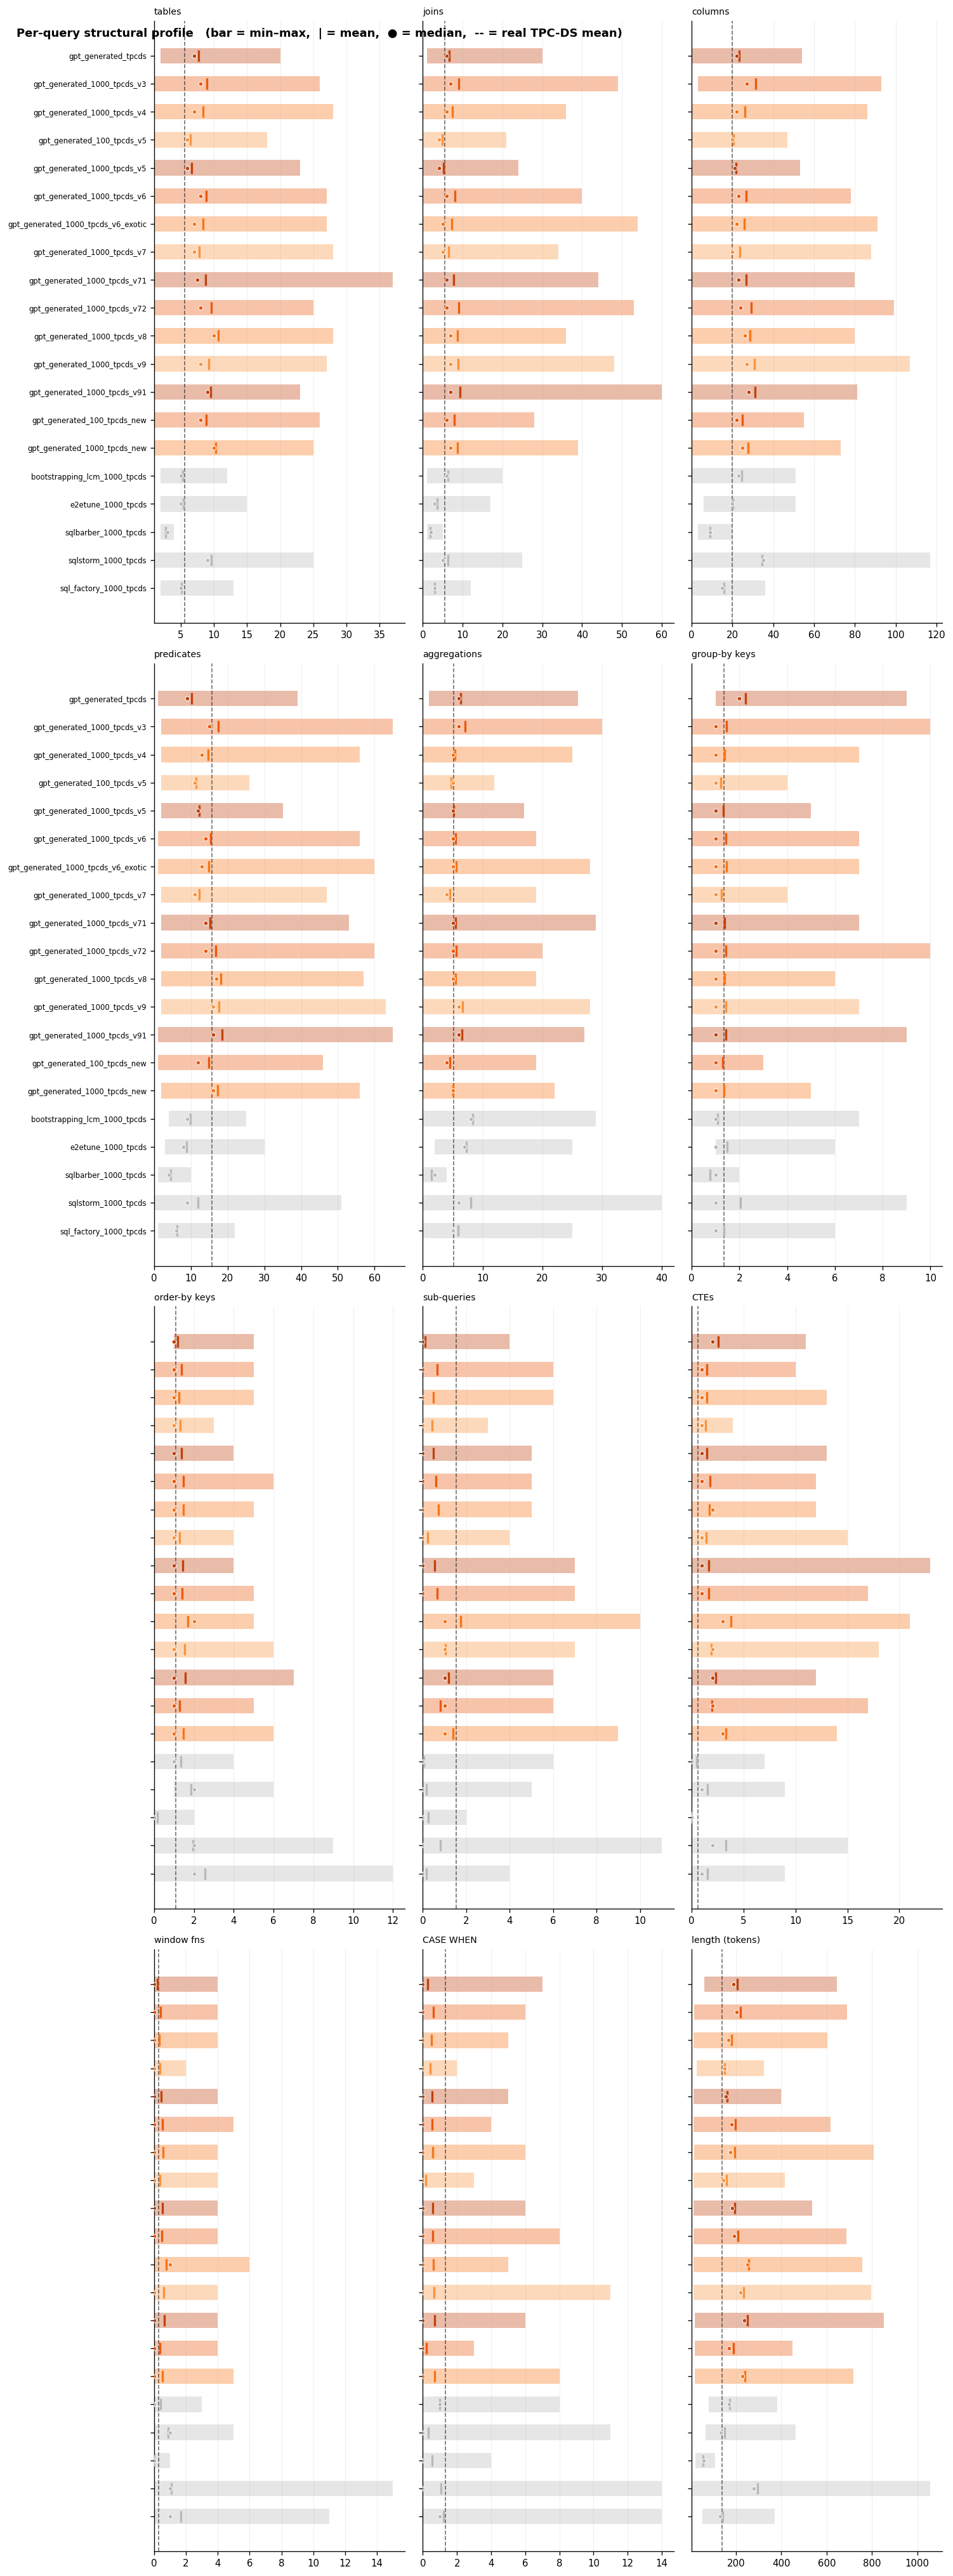

In [113]:
FEATURES = {
    "num_tables":           "tables",
    "num_joins":            "joins",
    "num_columns":          "columns",
    "num_predicates":       "predicates",
    "num_aggregations":     "aggregations",
    "num_group_by":         "group-by keys",
    "num_order_by":         "order-by keys",
    "num_subqueries":       "sub-queries",
    "num_ctes":             "CTEs",
    "num_window_functions": "window fns",
    "num_case_when":        "CASE WHEN",
    "query_length_tokens":  "length (tokens)",
}

def feat(w, f, stat):
    return float(df.loc[w, f"meta_{f}_{stat}"])

ncols = 3
nrows = int(np.ceil(len(FEATURES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 0.42 * len(ORDER) * nrows + 0.6))
axes = np.atleast_1d(axes).ravel()
for ax, (f, label) in zip(axes, FEATURES.items()):
    for i, w in enumerate(ORDER):
        lo, hi = feat(w, f, "min"), feat(w, f, "max")
        ax.barh(i, max(hi - lo, 1e-9), left=lo, height=0.55,
                color=COL[w], alpha=0.35, zorder=1)
        ax.plot([feat(w, f, "mean")], [i], "|", color=COL[w], ms=11, mew=2, zorder=3)
        ax.plot([feat(w, f, "median")], [i], "o", color=COL[w], ms=4,
                mec="white", mew=0.6, zorder=3)
    if REF in df.index:
        ax.axvline(feat(REF, f, "mean"), color="#111", ls="--", lw=1, alpha=.6, zorder=2)
    ax.set_yticks(range(len(ORDER)))
    ax.set_yticklabels(ORDER if ax in (axes[0], axes[ncols]) else [], fontsize=7)
    ax.invert_yaxis(); ax.set_title(label, fontsize=8.5, loc="left")
    ax.grid(axis="y", visible=False)
for ax in axes[len(FEATURES):]:
    ax.axis("off")
fig.suptitle("Per-query structural profile   "
             "(bar = min–max,  | = mean,  ● = median,  -- = real TPC-DS mean)",
             x=0.02, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

### (7) Complexity mix

Each generator's split of low / medium / high-complexity queries (from the static
SQL feature extractor). A healthy analytical workload leans medium/high.

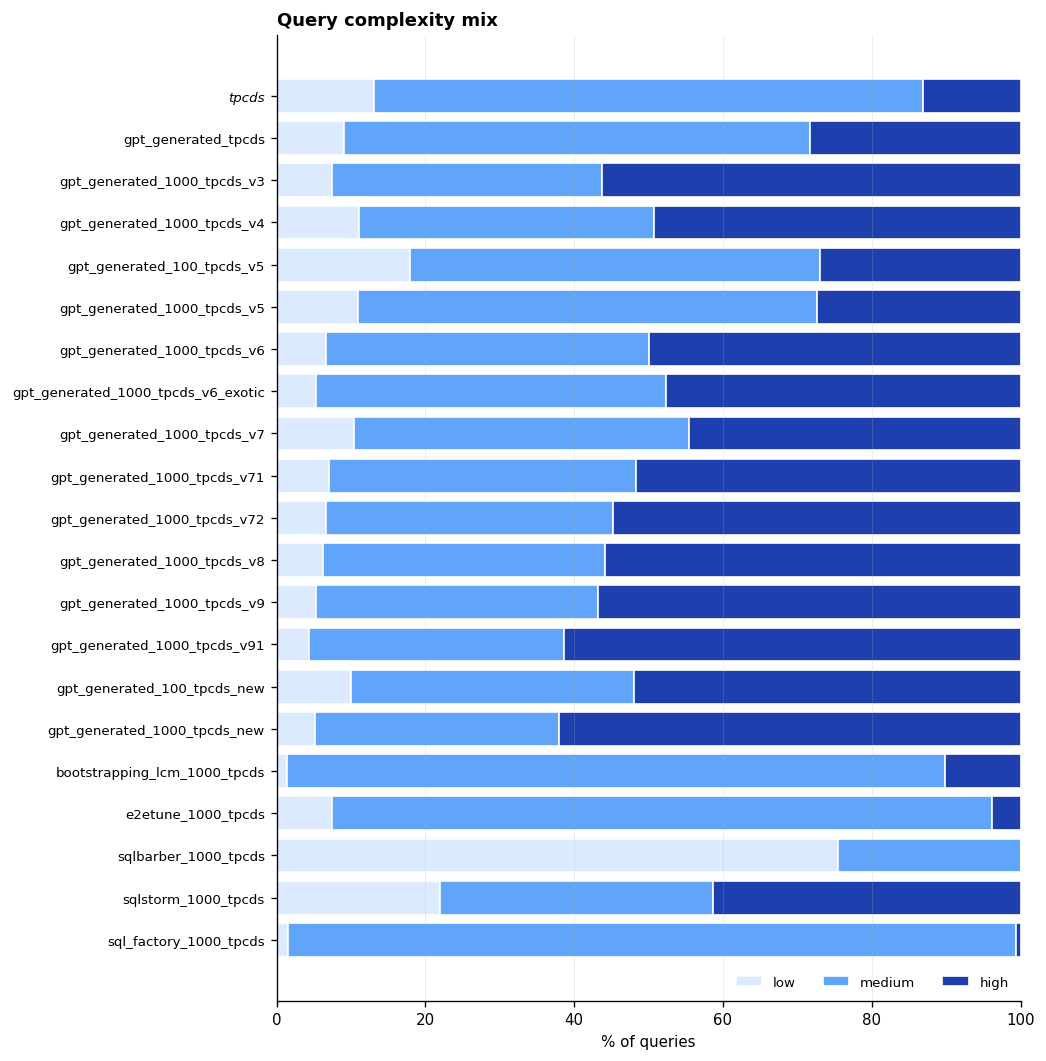

,low,medium,high
workload,,,
tpcds,13.1,73.7,13.1
gpt_generated_tpcds,9.1,62.6,28.3
gpt_generated_1000_tpcds_v3,7.4,36.4,56.2
gpt_generated_1000_tpcds_v4,11.1,39.7,49.2
gpt_generated_100_tpcds_v5,18.0,55.0,27.0
gpt_generated_1000_tpcds_v5,11.0,61.7,27.3
gpt_generated_1000_tpcds_v6,6.7,43.3,50.0
gpt_generated_1000_tpcds_v6_exotic,5.3,47.1,47.6
gpt_generated_1000_tpcds_v7,10.4,45.1,44.5


In [114]:
mix_cols = ["meta_complexity_low_pct", "meta_complexity_medium_pct", "meta_complexity_high_pct"]
mix = df.loc[ROWS, mix_cols].astype(float)
mix.columns = ["low", "medium", "high"]

fig, ax = plt.subplots(figsize=(8, 0.45 * len(ROWS) + 1))
shades = ["#dbeafe", "#60a5fa", "#1e40af"]
left = np.zeros(len(ROWS))
for c, sh in zip(mix.columns, shades):
    ax.barh(range(len(ROWS)), mix[c].values, left=left, color=sh,
            edgecolor="white", label=c)
    left += mix[c].values
ax.set_yticks(range(len(ROWS))); ax.set_yticklabels(ROWS, fontsize=8)
ax.get_yticklabels()[0].set_fontstyle("italic")
ax.invert_yaxis(); ax.set_xlabel("% of queries")
ax.legend(frameon=False, ncol=3, fontsize=8, loc="lower right")
ax.set_title("Query complexity mix", loc="left", fontweight="bold")
ax.grid(axis="y", visible=False)
plt.show()

show(mix, "{:.1f}")